# Partie A: Clustering

- **Dataset**: Mall Customer Segmentation Data
- **Objectifs**: Segmenter les clients du centre commercial en groupes homogènes.

In [78]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# PCA et KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Chargement:
Chargement du fichier `Mall_Customer.csv`

In [79]:
# Chargement du DataSet
dataset=pd.read_csv('../dataset/Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 2. Nettoyage et prétraitement:

In [ ]:
# Nettoyage et prétraitement
## Gender : Supprimer les NaN
dataset['Gender'].dropna(inplace=True)
##  TODO Age: Superieure à 18
dataset['Age']=dataset['Age'].fillna(18)

## TODO Annual Income: Positifs

## TODO Spending Score: Entre 1-100

## Gender Remplacer:
##   Male   par 0
##   Female par 1
#dataset['Gender_encode']=dataset['Gender'].replace({"Male":0,"Female":1})
dataset['Gender_encode']=dataset['Gender'].({"Male":0,"Female":1})
dataset.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encode
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


# 3. EDA univariée et multivariée :

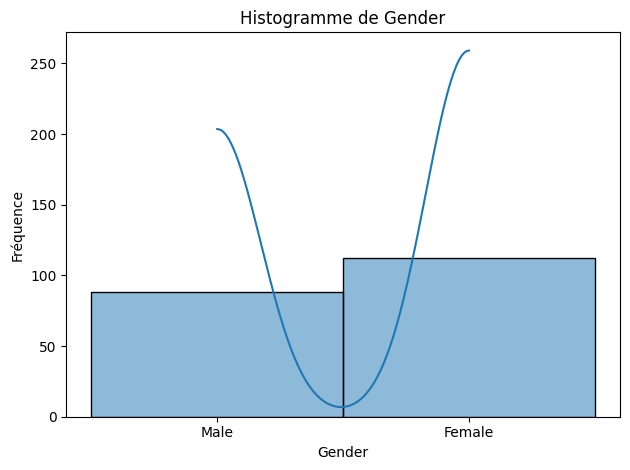

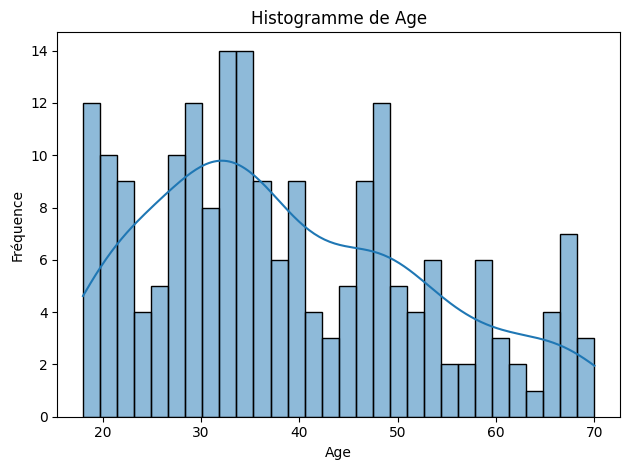

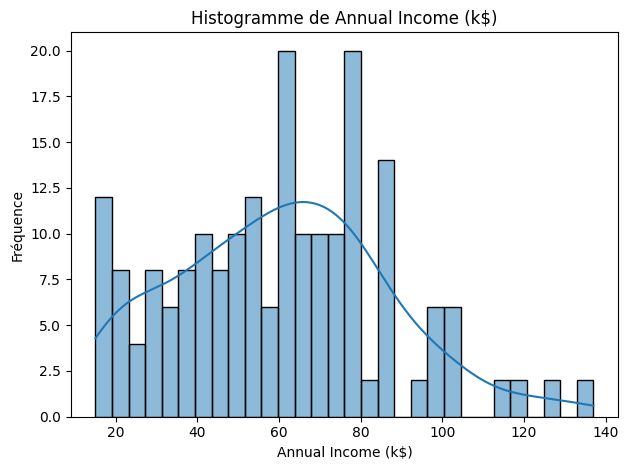

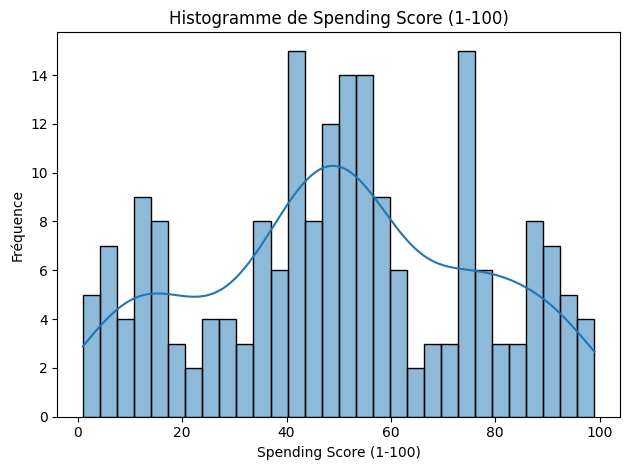

In [81]:
# Histogramme de Chaque Variables
dataset_ex=dataset.drop(["CustomerID","Gender_encode"],axis=1)
#dataset_ex.hist(figsize=(10, 8), bins=20)
#plt.tight_layout()
#plt.show()

# Affichage en Seaborn
#for column in dataset_ex.select_dtypes(include='number').columns:
for column in dataset_ex.columns:
    #plt.figure(figsize=(6, 4))
    plt.figure()
    sns.histplot(dataset_ex[column], kde=True, bins=30)
    plt.title(f"Histogramme de {column}")
    plt.xlabel(column)
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()

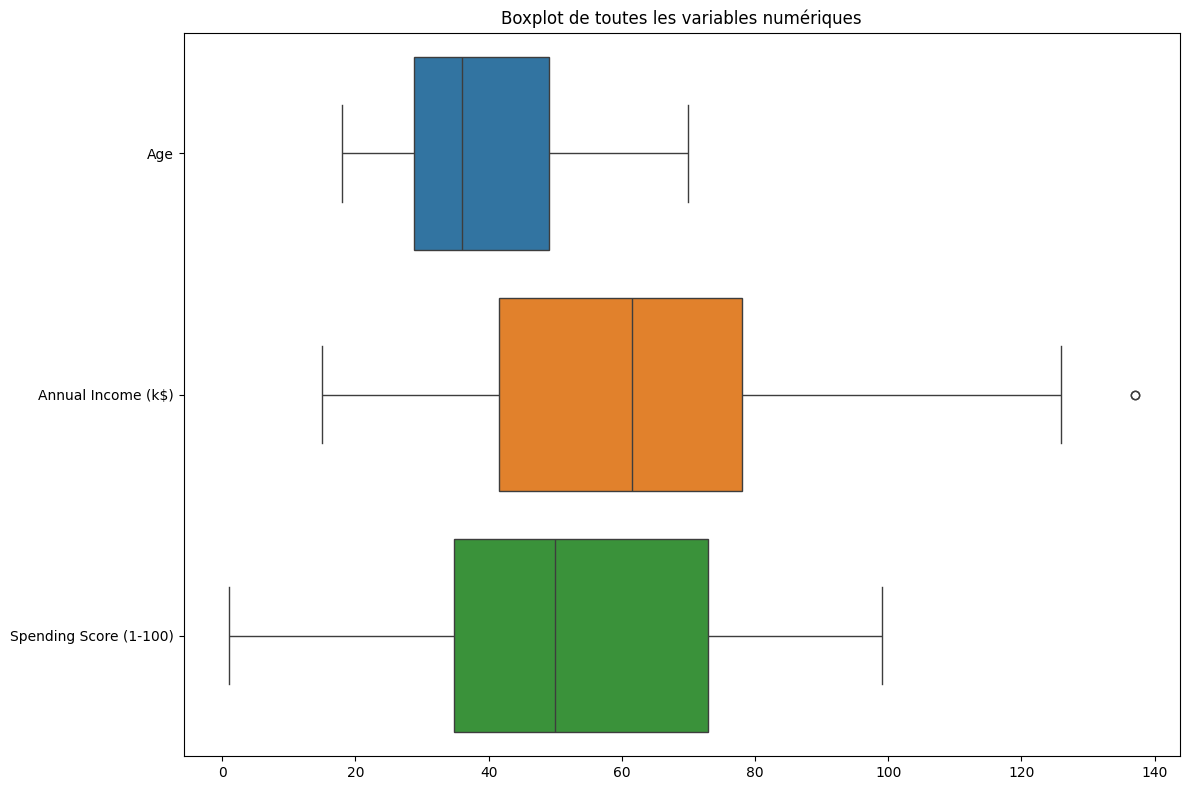

In [82]:
# BoxLayout de Chaque Variables
# TODO : Modifier en Subplot pour chaque Variable
#dataset.boxplot(figsize=(10, 8))
#plt.tight_layout()
#plt.show()
# Boucler sur chaque variable numérique
"""for column in dataset_ex.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=dataset_ex[column])
    plt.title(f"Boxplot de {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()
"""
# Exemple avec
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset_ex.select_dtypes(include='number'), orient="h")
plt.title("Boxplot de toutes les variables numériques")
plt.tight_layout()
plt.show()

La matrice de Correlation :                              Age  Annual Income (k$)  Spending Score (1-100)  \
Age                     1.000000           -0.012398               -0.327227   
Annual Income (k$)     -0.012398            1.000000                0.009903   
Spending Score (1-100) -0.327227            0.009903                1.000000   
Gender_encode          -0.060867           -0.056410                0.058109   

                        Gender_encode  
Age                         -0.060867  
Annual Income (k$)          -0.056410  
Spending Score (1-100)       0.058109  
Gender_encode                1.000000  


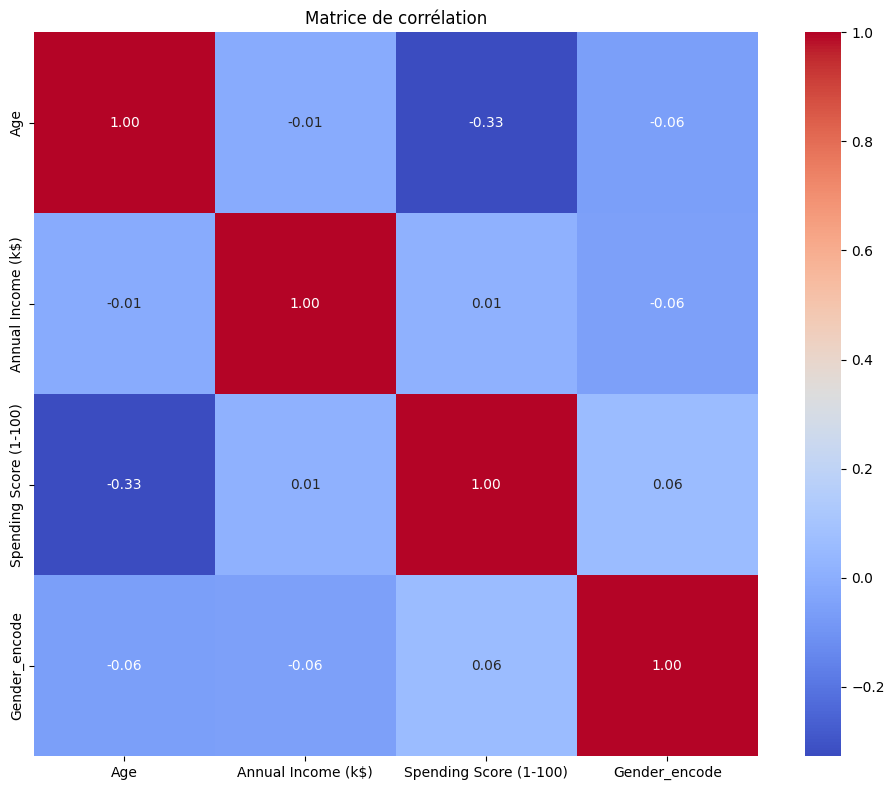

In [83]:
# Matrice de Correlation
dataset_en=dataset.drop(["Gender","CustomerID"],axis=1)
corr_matrix=dataset_en.corr()
print("La matrice de Correlation :",corr_matrix)

# TODO :Affichage en Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# Scatter Plot
#sns.pairplot(dataset, kind='scatter')
#plt.show()

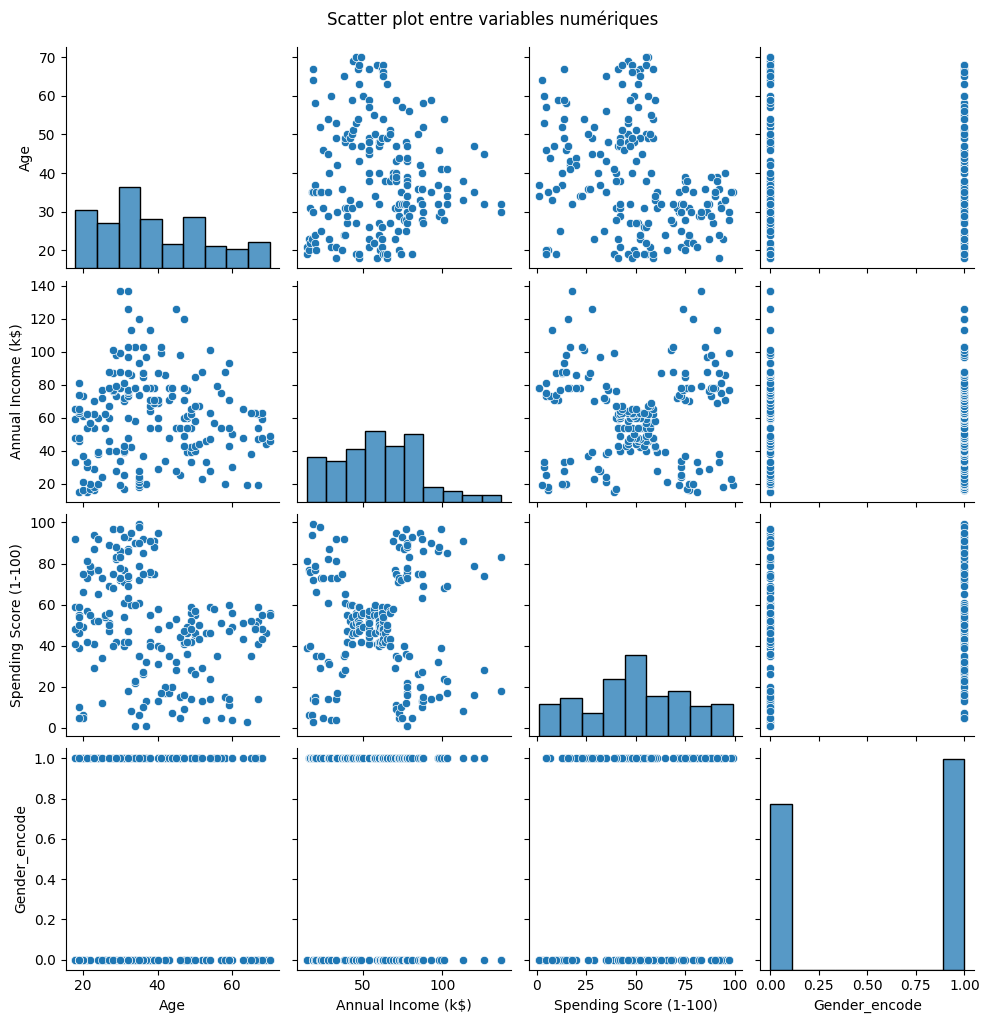

'sns.scatterplot(data=dataset_en, x="Age", y="Gender_encode")  # Remplace col1 et col2\nplt.title("Scatter plot entre col1 et col2")\nplt.xlabel("col1")\nplt.ylabel("col2")\nplt.show()'

In [88]:
# Scatter Plot de Chaque Variables
sns.pairplot(dataset_en.select_dtypes(include='number'))
plt.suptitle("Scatter plot entre variables numériques", y=1.02)
plt.show()

"""sns.scatterplot(data=dataset_en, x="Age", y="Gender_encode")  # Remplace col1 et col2
plt.title("Scatter plot entre col1 et col2")
plt.xlabel("col1")
plt.ylabel("col2")
plt.show()"""


# 4. Feature engineering / sélection: 

In [85]:
# Supprimer les features non informatives et Redondantes
## Supprimer CustomerID car non-informatives
dataset_select=dataset.drop(['CustomerID','Gender'], axis=1)
dataset_select.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_encode
0,19,15,39,0
1,21,15,81,0
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1


In [86]:
# Categoriser des Variables
# TODO:
## Categoriser en Classe d'Age
## 19-24: Classe 1
## 25-39: Classe 2

# A modifier
def classe_age(value):
    if(value>25):
        return "Adulte"
    else:
        return "Jeune"

dataset_classe=dataset
dataset_classe["Classe Age"]=dataset["Age"].map(lambda x:classe_age(x))
dataset_classe.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encode,Classe Age
0,1,Male,19,15,39,0,Jeune
1,2,Male,21,15,81,0,Jeune
2,3,Female,20,16,6,1,Jeune
3,4,Female,23,16,77,1,Jeune
4,5,Female,31,17,40,1,Adulte


# 5. Reduction de Dimension:


In [73]:
# Application de PCA pour la Visualisation en 2D
pca = PCA(n_components=2) # 2 Composants

# Separer les features des Targets (X et Y)
## Features: Gender, Age , Annual Income
## Target : Spending Score

X=dataset_select.drop("Spending Score (1-100)",axis=1) # Exclure Spending Score
Y=dataset_select["Spending Score (1-100)"]

# Application du PCA pour Reduire en 2 dimension
X_pca=pca.fit_transform(X)

#Conversion en Dataframe
df_pca=pd.DataFrame(data=X_pca,columns=['component1','component2'])

df_pca.head()

,component1,component2
0,-45.374976,-20.266595
1,-45.393362,-18.266684
2,-44.385275,-19.259655
3,-44.412854,-16.259789
4,-43.486439,-8.250956


# 6. Clustering

In [74]:
# Clustering K means

## Variables pour Stocker les Resultats
inertias = []
silhouettes = []
K_range = range(2, 7)

## 
for i, k in enumerate(K_range, 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# 
print("Elbow:",inertias)
print("Silhouette",silhouettes)

Elbow: [87228.95732689211, 59574.61698578636, 39551.60942422729, 32820.2253968254, 25796.078872994825]
Silhouette [0.42272827955403725, 0.42270759995315615, 0.4331549993604238, 0.40145047457459926, 0.40173227570540376]


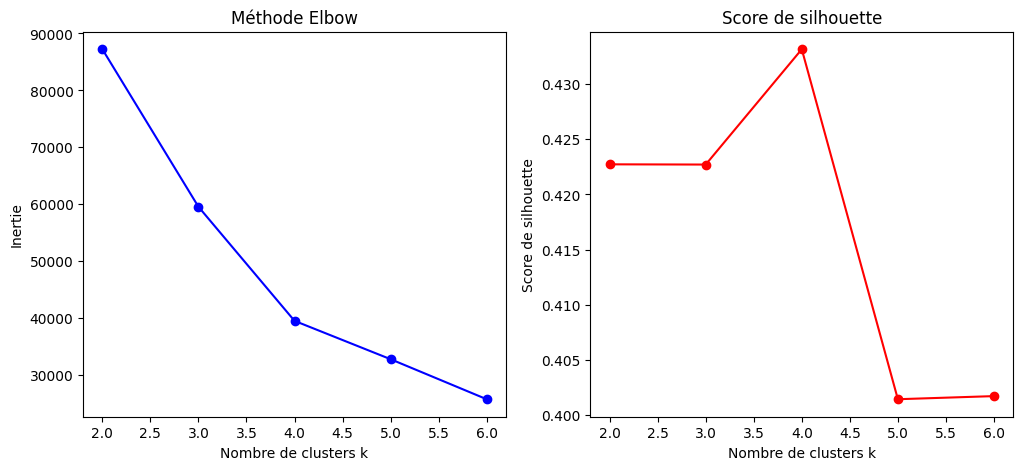

In [75]:
# Affichage de Elbow et Sihouettes

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Méthode Elbow')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette')

plt.show()

# 7. Interpretation des Clusters

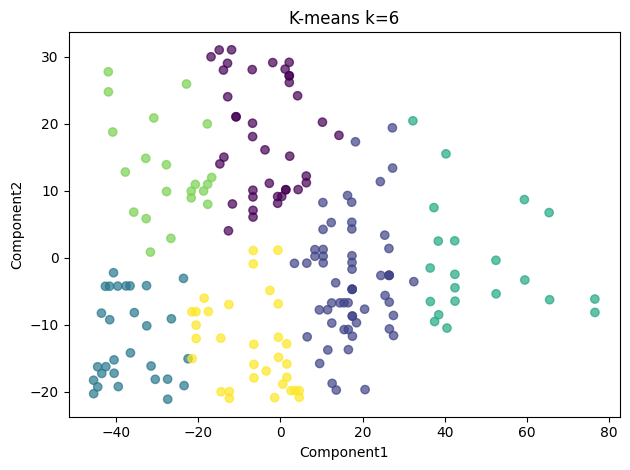

In [76]:
# Analyses Des Centroides

# TODO : analyse des centroides

# Visualisation 2D Coloré par Cluster
#plt.figure(figsize=(15, 5))

#for i, k in enumerate(K_range, 1):
    # Visualisation clusters en 2D
#plt.subplot(1, len(K_range), i)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f'K-means k={k}')
plt.xlabel('Component1')
plt.ylabel('Component2')

plt.tight_layout()
plt.show()